In [1]:
import torch
 
print(f"PyTorch version {torch.__version__}")
if torch.cuda.is_available():
    print("CUDA GPU")
elif torch.xpu.is_available():
    print("Intel GPU")
elif torch.mps.is_available():
    print("Apple Silicon GPU")
 
else:
    print("Only CPU")

PyTorch version 2.11.0
Apple Silicon GPU


In [16]:
from pathlib import Path
from reasoning_from_scratch.qwen3 import download_qwen3_small
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer


# Define the output directory and ensure it exists
out_dir = Path("../../_models/qwen3").resolve()
out_dir.mkdir(parents=True, exist_ok=True)

download_qwen3_small(kind="base", tokenizer_only=False, out_dir=str(out_dir))
#download_qwen3_small(kind="base", tokenizer_only=True, out_dir=str(out_dir))
tokenizer_path = Path(str(out_dir)) / "tokenizer-base.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)

qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


In [17]:
# 2.4 Preparing Input for Text Generations
# We will do Tokenization Round Trip. i.e. encode a text into token IDs and decode those IDs back to Text
prompt = "Explain large language models."

input_token_ids_list = tokenizer.encode(prompt) # outputs a list. 
print(input_token_ids_list)

text = tokenizer.decode(input_token_ids_list)
print(text)
print("\n")

for i in input_token_ids_list:
    print(f"{[i]} --> {tokenizer.decode([i])}")

[840, 20772, 3460, 4128, 4119, 13]
Explain large language models.


[840] --> Ex
[20772] --> plain
[3460] -->  large
[4128] -->  language
[4119] -->  models
[13] --> .


"Explain" was split into two separate tokens, "Ex" and "plain". This is because the tokenizer algorithm uses a subword-based method based on Byte Pair Encoding (BPE). BPE can represent both common and rare words using a mix of full words and subword units. Spaces are also often included in tokens (for example, " large"), which helps the LLM detect word boundaries.

The Qwen3Tokenizer - Vocab Size - 151,000 tokens. A larger vocabulary in a language model increases its size and computational cost for each individually generated token, but it also allows more words to be represented as single tokens rather than being split into subword components. This is beneficial because splitting a word (like breaking "Explain" into "Ex" and "plain") results in more input tokens. 

More tokens lead to longer input sequences, which increases processing time and resource usage. 


In [18]:
# Note that if you have a modern NVIDIA GPU (based on the Ampere architecture or newer), the get_device() function automatically enables Tensor Cores for faster matrix multiplications when enable_tensor_cores=True.


def get_device(enable_tensor_cores=True):
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using NVIDIA CUDA GPU")
        
        if enable_tensor_cores:
            major, minor = map(int, torch.__version__.split(".")[:2])
            if (major, minor) >= (2, 9):
                torch.backends.cuda.matmul.fp32_precision = "tf32"
                torch.backends.cudnn.conv.fp32_precision = "tf32"
            else:
                torch.backends.cuda.matmul.allow_tf32 = True
                torch.backends.cudnn.allow_tf32 = True
 
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple Silicon GPU (MPS)")
 
    elif torch.xpu.is_available():
        device = torch.device("xpu")
        print("Using Intel GPU")
 
    else:
        device = torch.device("cpu")
        print("Using CPU")
 
    return device

In [19]:
from reasoning_from_scratch.qwen3 import Qwen3Model, QWEN_CONFIG_06_B
 
model_path = Path(str(out_dir)) / "qwen3-0.6B-base.pth"
model = Qwen3Model(QWEN_CONFIG_06_B)
model.load_state_dict(torch.load(model_path))
model.to(get_device())

Using Apple Silicon GPU (MPS)


Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

Input text is tokenized and passed through an embedding layer, followed by 28 repeated transformer blocks. Each block contains grouped-query attention, feedforward layers, and RMS normalization. The model ends with a final normalization and linear output layer. Arrows show the data flow through the model.


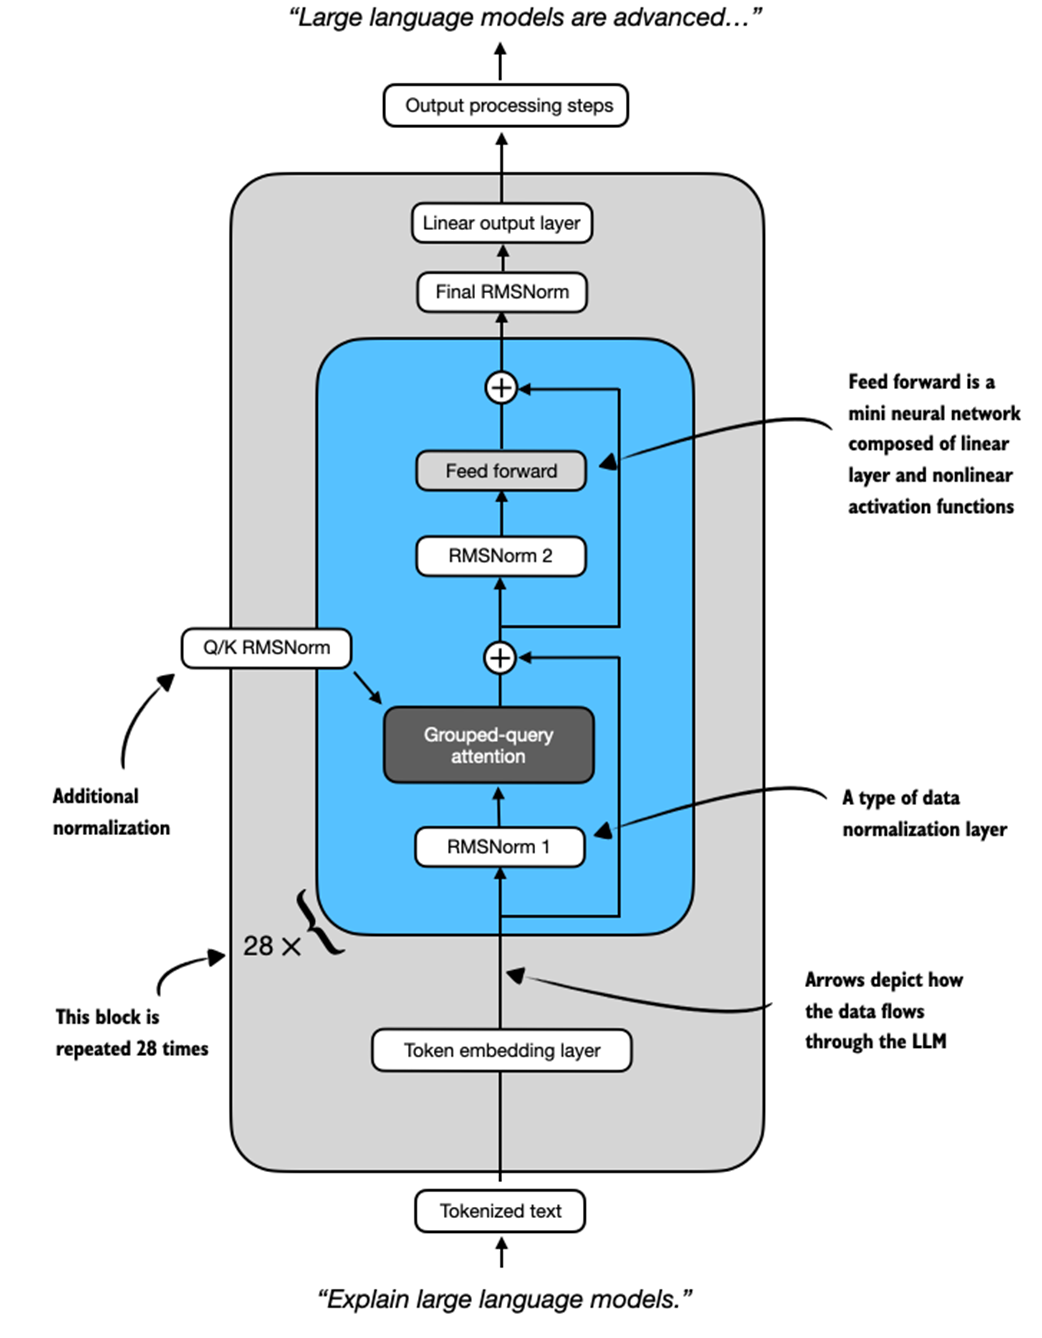